<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from fastai.vision.all import *
from monai.utils import set_determinism
set_determinism(0)
# from sklearn.model_selection import train_test_split

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Data

In [ ]:
bs, size = 8, 2048
# arch = models.resnet34
path = Path('../../bioMONAI_0/_data/Babesia')
#path = Path('../_data/Babesia/')
path_x = path/'RI_recorted'
path_y = path/'TRITC'

In [ ]:
from bioMONAI.core import get_target
get_target(path_y, same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC')(path / 'O11_RI_frame01.tiff')

Path('../../bioMONAI_0/_data/Babesia/TRITC/O11_TRITC_frame01.tiff')

### Look at training data

In [ ]:
from monai.transforms import ScaleIntensity

item_tfms = [ScaleIntensity(minv=0.0, maxv=1.0),
             RandCropND(size), 
             RandRot90(prob=0.5), 
             RandFlip(prob=0.75),
             ]

Setting-up type transforms pipelines
Found 275 items
2 datasets of sizes 220,55
Setting up Pipeline: BioImageMulti.create
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImage.create

Building one sample
  Pipeline: BioImageMulti.create
    starting from
      ../../bioMONAI_0/_data/Babesia/RI_recorted/O11_RI_frame10.tiff
    applying BioImageMulti.create gives
      BioImageMulti of size 20x512x512
  Pipeline: get_target.<locals>.generate_target_path -> BioImage.create
    starting from
      ../../bioMONAI_0/_data/Babesia/RI_recorted/O11_RI_frame10.tiff
    applying get_target.<locals>.generate_target_path gives
      ../../bioMONAI_0/_data/Babesia/TRITC/O11_TRITC_frame10.tiff
    applying BioImage.create gives
      BioImage of size 1x512x512

Final sample: (BioImageMulti([[[46., 46., 46.,  ..., 46., 46., 46.],
         [46., 46., 46.,  ..., 46., 46., 46.],
         [46., 46., 46.,  ..., 46., 46., 46.],
         ...,
         [46., 46., 46.,  ..., 46., 46., 46.],

Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.



No before_batch transform to apply

Collating items in a batch

Applying batch_tfms to the batch built
  Pipeline: Tensor2BioImage -- {}
    starting from
      (MetaTensor of size 4x20x512x512, MetaTensor of size 4x1x512x512)
    applying Tensor2BioImage -- {} gives
      (BioImage of size 4x20x512x512, BioImage of size 4x1x512x512)


Setting affine, but the applied meta contains an affine. This will be overwritten.


TypeError: Invalid shape (20, 512, 512) for image data

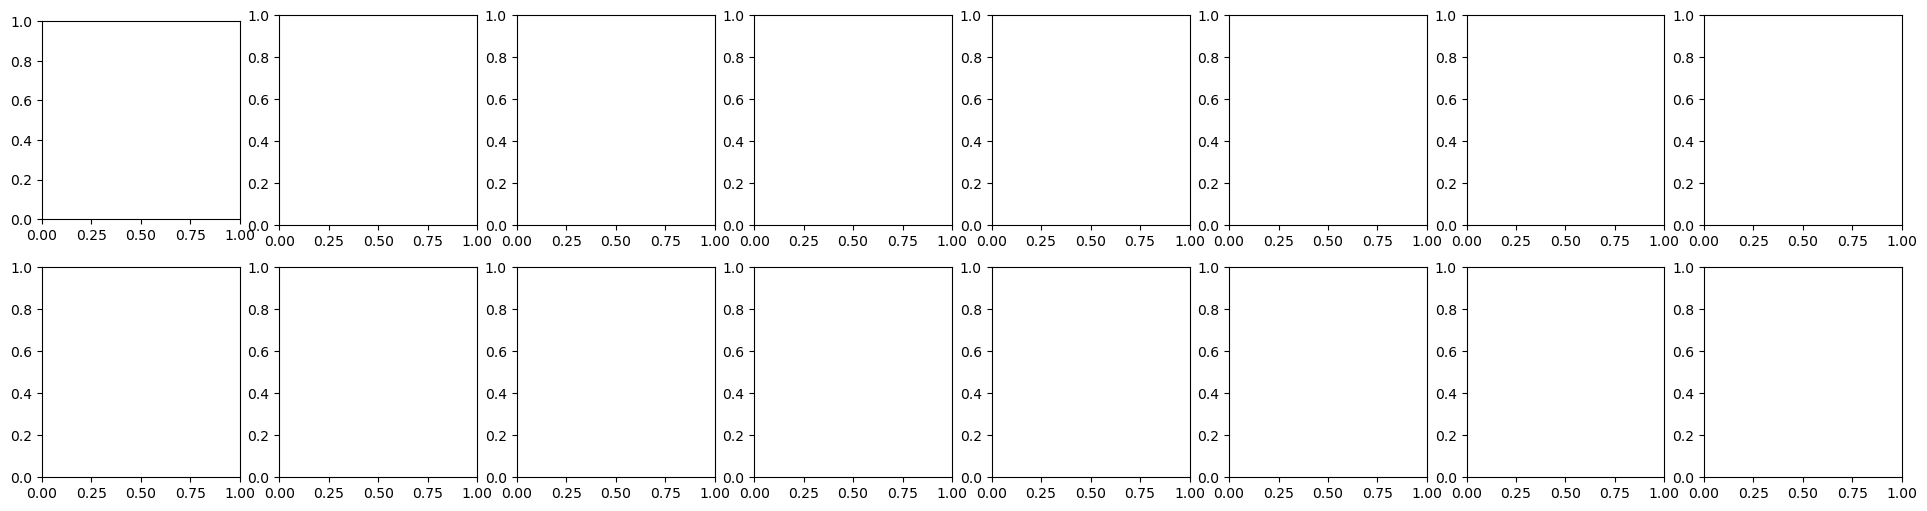

In [ ]:
from bioMONAI.core import get_target

dblock = DataBlock(blocks=(BioImageBlock(cls=BioImageMulti), BioImageBlock(cls=BioImage)),
                   get_items=get_image_files,
                   get_y=get_target(path_y, same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC'),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=item_tfms,
                   )

dblock.summary(path_x)

dls = dblock.dataloaders(path_x, bs=bs)
#dls.show_batch(max_n=8, cmap='gray')

In [ ]:
# training and validation
len(dls.train_ds.items), len(dls.valid_ds.items)

(220, 55)

### Create and train a 2D model

In [ ]:
from monai.networks.nets import BasicUNet # AttentionUnet, DynUNet, UNet, BasicUNet

In [ ]:
# model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64, 128, 256),strides=(2, 2, 2, 2), num_res_units=2).model
#model = UNet(spatial_dims=2, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 2, 2), num_res_units=2).model
# model = AttentionUnet(spatial_dims=2, in_channels=1, out_channels=1, channels=(16, 32, 64),strides=(1, 1))
# model = DynUNet(spatial_dims=2, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True) # it tends to create hot pixels
model = BasicUNet(spatial_dims=2, in_channels=1, out_channels=1)

BasicUNet features: (32, 32, 64, 128, 256, 32).


In [ ]:
from bioMONAI.losses import CombinedLoss
loss_func = mse #CombinedLoss()

In [ ]:
from bioMONAI.losses import SSIMMetric

metrics = [mae, mse, SSIMMetric]

In [ ]:
# learn = Learner(dls, model, loss_func=loss_func, opt_func=ranger, metrics=nn.L1Loss)
learn = Learner(dls, model, loss_func=loss_func, metrics=metrics, cbs=ShowGraphCallback())

In [ ]:
learn.summary()

Setting affine, but the applied meta contains an affine. This will be overwritten.


RuntimeError: Given groups=1, weight of size [32, 1, 3, 3], expected input[1, 20, 512, 512] to have 1 channels, but got 20 channels instead

SuggestedLRs(valley=0.0014454397605732083)


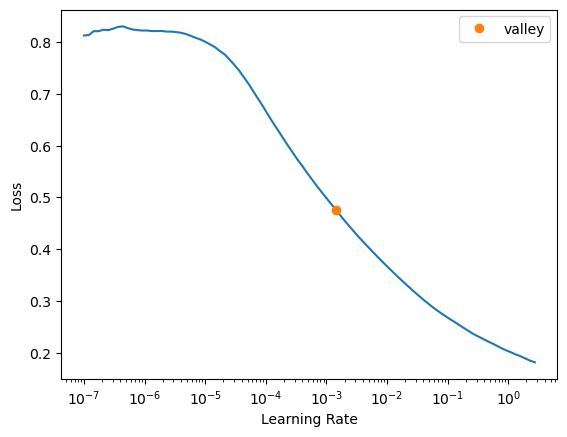

In [ ]:
# lr = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))
lr = learn.lr_find(suggest_funcs=(valley))
print(lr)

In [ ]:
lr = float('%.1g'%(lr))
print(lr)

0.001


epoch,train_loss,valid_loss,mae,mse,SSIM,time
0,0.109584,0.041494,0.097367,0.041494,0.324422,00:08
1,0.060264,0.023976,0.049804,0.023976,0.618451,00:08
2,0.039415,0.015518,0.038897,0.015518,0.688535,00:08
3,0.026590,0.009562,0.029468,0.009562,0.770245,00:08
4,0.018046,0.005771,0.024451,0.005771,0.793338,00:08
5,0.012177,0.003407,0.021684,0.003407,0.800922,00:08
6,0.008114,0.002048,0.019917,0.002048,0.807107,00:08
7,0.005418,0.001393,0.018134,0.001393,0.821040,00:09
8,0.003652,0.001091,0.017880,0.001091,0.824217,00:08
9,0.002569,0.000987,0.016848,0.000987,0.830604,00:08


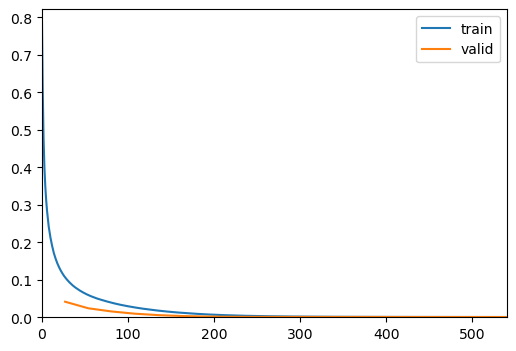

In [ ]:
learn.fit_flat_cos(20,lr)

In [ ]:
learn.show_results(cmap='gray')

In [ ]:
# learn.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!

### Export learner

In [ ]:
# store_variables(pkl_fn='vars.pkl', size=size, reorder=reorder,  resample=resample)

In [ ]:
# learn.export('______.pkl')